# 🦅 Optimasi Rantai Pasok Dingin Multi-Horison Menggunakan Aquila Optimizer (AO)

Notebook ini memformulasikan model rantai pasok dingin (cold chain) untuk pengiriman komoditas peka suhu (seperti vaksin medis sensitif atau bahan pangan segar). Kami mendefinisikan laju penurunan kualitas komoditas menggunakan **Persamaan Kinetika Arrhenius** dan menghitung biaya refrigerasi fisik.

Kami mengimplementasikan **Aquila Optimizer (AO)** dari nol untuk mencari proporsi alokasi moda logistik optimal ($x = [x_{\text{standard}}, x_{\text{second}}, x_{\text{first}}, x_{\text{same\_day}}]$) yang meminimalkan total biaya (biaya transportasi + biaya energi refrigerasi) di bawah batasan kualitas tiba produk aman ($\ge 85\%$).

Sebagai pembeda akademis untuk laporan dan artikel ilmiah, kami melakukan **analisis perbandingan multi-horison peramalan (Daily, Weekly, Monthly)** untuk mengevaluasi bagaimana perbedaan rentang waktu perencanaan memengaruhi biaya operasional logistik dan kualitas akhir produk tiba.

## 1. Formulasi Matematika Rantai Pasok Dingin

### A. Penurunan Kualitas Komoditas (Arrhenius Orde Kesatu)
Kualitas komoditas peka suhu saat tiba di tujuan dihitung sebagai:
$$Q = Q_0 \cdot e^{-k(T) \cdot t}$$
Konstanta laju pembusukan $k(T)$ berbasis suhu kontainer pendingin mengikuti hukum Arrhenius:
$$k(T) = A \cdot e^{-\frac{E_a}{R \cdot T}}$$

### B. Konsumsi Energi Refrigerasi Kontainer
Biaya refrigerasi sebanding dengan perbedaan suhu luar (ambient) dengan suhu kontainer pengiriman, dikalikan dengan waktu tempuh:
$$C_{refrig} = P_{energy} \cdot \max(0, T_{ambient} - T_{container}) \cdot t$$

### C. Fungsi Kebugaran (Fitness Function)
Optimasi bertujuan meminimalkan biaya logistik total per unit perencanaan:
$$TC = \sum_{m=1}^{4} x_m \cdot D \cdot (C_{trans, m} + C_{refrig, m}) + \text{Penalty}(Q)$$
Dengan batasan (*constraints*):
*   $\sum_{m=1}^4 x_m = 1$ (proporsi alokasi moda pengiriman, $x_m \ge 0$)
*   Kapasitas operasional: $x_{\text{standard}} \ge 0.20$, $x_{\text{second}} \le 0.40$, $x_{\text{first}} \le 0.30$, $x_{\text{same\_day}} \le 0.15$
*   Standar kualitas tiba minimum: $\sum_{m=1}^4 x_m \cdot Q_m \ge 85.0\%$

## 2. Impor Pustaka & Setup Parameter Fisik

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 6)

# Parameter Arrhenius Kualitas Produk
Q0 = 100.0
Ea = 60000.0
A_decay = 8e9
R_gas = 8.314

# Properti Moda Pengiriman
times = np.array([4.0, 2.0, 1.0, 0.5])
T_container_C = np.array([8.0, 4.0, 2.0, 1.0])
T_container_K = T_container_C + 273.15
c_trans = np.array([1.5, 3.0, 6.0, 12.0])

P_energy = 0.015

# Batasan Kapasitas (Constraints)
min_capacity = np.array([0.20, 0.0, 0.0, 0.0])
max_capacity = np.array([1.0, 0.40, 0.30, 0.15])
min_avg_quality = 85.0

# Hitung Kualitas Tiba
k_decay = A_decay * np.exp(-Ea / (R_gas * T_container_K))
Q_arrival = Q0 * np.exp(-k_decay * times)

print("Laju kerusakan per hari (k):", k_decay)
print("Kualitas produk saat tiba (%):", Q_arrival)

Laju kerusakan per hari (k): [0.05692906 0.03930454 0.03252691 0.02955923]
Kualitas produk saat tiba (%): [79.63502032 92.44012229 96.79963988 98.53290665]


## 3. Fitness Function dengan Metode Penalti

In [2]:
def compute_fitness(x, demand, ambient_temp):
    x = np.abs(x)
    sum_x = np.sum(x)
    if sum_x == 0:
        x = np.ones(len(x)) / len(x)
    else:
        x = x / sum_x
        
    # 1. Biaya Transportasi
    cost_trans = demand * np.sum(x * c_trans)
    
    # 2. Biaya Energi Pendinginan
    temp_diff = np.clip(ambient_temp - T_container_C, a_min=0.0, a_max=None)
    cost_refrig = demand * np.sum(x * P_energy * temp_diff * times)
    
    # 3. Kualitas Tiba
    avg_quality = np.sum(x * Q_arrival)
    
    # Penalti
    penalty = 0.0
    for i in range(len(x)):
        if x[i] > max_capacity[i]:
            penalty += (x[i] - max_capacity[i]) ** 2 * 50000.0
        if x[i] < min_capacity[i]:
            penalty += (min_capacity[i] - x[i]) ** 2 * 50000.0
            
    if avg_quality < min_avg_quality:
        penalty += (min_avg_quality - avg_quality) ** 2 * 50000.0
        
    total_fitness = cost_trans + cost_refrig + penalty
    return total_fitness, cost_trans, cost_refrig, x, avg_quality

## 4. Implementasi Aquila Optimizer (AO) dari Nol

In [3]:
def levy_flight(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) / 
             (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1.0 / beta)
    u = np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    step = u / (np.abs(v)**(1.0 / beta))
    return step

def run_aquila_optimizer(demand, ambient_temp, max_iter=100, pop_size=40, dim=4, lb=0.0, ub=1.0):
    X = np.random.uniform(lb, ub, (pop_size, dim))
    best_X = np.zeros(dim)
    best_fitness = float('inf')
    
    alpha = 0.1
    delta = 0.1
    
    for t in range(max_iter):
        X_mean = np.mean(X, axis=0)
        
        for i in range(pop_size):
            fit = compute_fitness(X[i], demand, ambient_temp)[0]
            if fit < best_fitness:
                best_fitness = fit
                best_X = X[i].copy()
                
        for i in range(pop_size):
            r1 = np.random.rand()
            if t <= (2.0 / 3.0) * max_iter:
                if np.random.rand() < 0.5:
                    X[i] = best_X * (1.0 - t / max_iter) + (X_mean - best_X) * np.random.rand()
                else:
                    X[i] = best_X * levy_flight(dim) + X[i] + (np.random.rand() * (ub - lb) + lb)
            else:
                if np.random.rand() < 0.5:
                    X[i] = (best_X - X_mean) * alpha - np.random.rand() + ((ub - lb) * np.random.rand() + lb) * delta
                else:
                    QF = t ** ((2.0 * np.random.rand() - 1.0) / (1.0 - max_iter)**2)
                    G1 = 2.0 * np.random.rand() - 1.0
                    G2 = 2.0 * (1.0 - t / max_iter)
                    X[i] = QF * best_X - (G1 * X[i] * np.random.rand()) - G2 * levy_flight(dim) + np.random.rand() * G1
            
            X[i] = np.clip(X[i], lb, ub)
            
    _, cost_trans_opt, cost_refrig_opt, final_x, avg_q = compute_fitness(best_X, demand, ambient_temp)
    return final_x, cost_trans_opt, cost_refrig_opt, avg_q

## 5. Eksekusi Optimasi Dinamis untuk Daily, Weekly, dan Monthly

In [4]:
def run_optimization_for_file(pred_file_name):
    pred_path = f'data/predicted/{pred_file_name}'
    df_pred = pd.read_csv(pred_path)
    
    opt_results = []
    for idx, row in df_pred.iterrows():
        date = row['date']
        demand = row['predicted_demand']
        temp = row['ambient_temp']
        
        final_x, trans, refrig, avg_q = run_aquila_optimizer(demand, temp, max_iter=100, pop_size=40)
        
        opt_results.append({
            'date': pd.to_datetime(date),
            'demand_predicted': demand,
            'ambient_temp': temp,
            'x_standard': final_x[0],
            'x_second': final_x[1],
            'x_first': final_x[2],
            'x_same_day': final_x[3],
            'cost_trans': trans,
            'cost_refrig': refrig,
            'total_cost_opt': trans + refrig,
            'avg_quality_opt': avg_q
        })
    
    df_opt = pd.DataFrame(opt_results)
    df_opt.set_index('date', inplace=True)
    return df_opt

print("1. Mengoptimalkan level Daily (Harian)... ")
df_opt_daily = run_optimization_for_file('daily_predictions.csv')

print("2. Mengoptimalkan level Weekly (Mingguan)... ")
df_opt_weekly = run_optimization_for_file('weekly_predictions.csv')

print("3. Mengoptimalkan level Monthly (Bulanan)... ")
df_opt_monthly = run_optimization_for_file('monthly_predictions.csv')

# Simpan hasil harian utama untuk kompatibilitas visualisasi berikutnya
out_dir = 'data/optimization'
os.makedirs(out_dir, exist_ok=True)
df_opt_daily.to_csv(os.path.join(out_dir, 'optimization_results.csv'))
df_opt_weekly.to_csv(os.path.join(out_dir, 'optimization_results_weekly.csv'))
df_opt_monthly.to_csv(os.path.join(out_dir, 'optimization_results_monthly.csv'))

print("Semua optimasi multi-horison selesai dan disimpan!")

1. Mengoptimalkan level Daily (Harian)... 


2. Mengoptimalkan level Weekly (Mingguan)... 


3. Mengoptimalkan level Monthly (Bulanan)... 


Semua optimasi multi-horison selesai dan disimpan!


## 6. Tabel Perbandingan Hasil Optimasi Multi-Horison

Untuk membandingkan performa secara adil (karena total demand test set harian, mingguan, dan bulanan sedikit berbeda akibat pembagian window), kita menghitung **biaya rata-rata per item (unit cost)** untuk transportasi dan refrigerasi.

In [5]:
def compute_summary_metrics(df_opt, label):
    total_demand = df_opt['demand_predicted'].sum()
    total_trans = df_opt['cost_trans'].sum()
    total_refrig = df_opt['cost_refrig'].sum()
    
    # Unit costs (USD/item)
    unit_trans = total_trans / total_demand
    unit_refrig = total_refrig / total_demand
    unit_total = (total_trans + total_refrig) / total_demand
    
    # Rata-rata tertimbang kualitas tiba
    weighted_quality = np.sum(df_opt['avg_quality_opt'] * df_opt['demand_predicted']) / total_demand
    
    # Rata-rata tertimbang proporsi moda
    p_standard = np.sum(df_opt['x_standard'] * df_opt['demand_predicted']) / total_demand * 100.0
    p_second = np.sum(df_opt['x_second'] * df_opt['demand_predicted']) / total_demand * 100.0
    p_first = np.sum(df_opt['x_first'] * df_opt['demand_predicted']) / total_demand * 100.0
    p_same_day = np.sum(df_opt['x_same_day'] * df_opt['demand_predicted']) / total_demand * 100.0
    
    return {
        'Planning Horizon': label,
        'Unit Trans Cost (USD/item)': unit_trans,
        'Unit Refrig Cost (USD/item)': unit_refrig,
        'Unit Total Cost (USD/item)': unit_total,
        'Avg Arrival Quality (%)': weighted_quality,
        'Standard Class (%)': p_standard,
        'Second Class (%)': p_second,
        'First Class (%)': p_first,
        'Same Day (%)': p_same_day
    }

summary_rows = [
    compute_summary_metrics(df_opt_daily, 'Daily (Harian - Operasional)'),
    compute_summary_metrics(df_opt_weekly, 'Weekly (Mingguan - Taktis)'),
    compute_summary_metrics(df_opt_monthly, 'Monthly (Bulanan - Strategis)')
]

df_comparison = pd.DataFrame(summary_rows).set_index('Planning Horizon')
print("=== TABEL PERBANDINGAN OPTIMASI MULTI-HORISON ===")
display(df_comparison.round(4))

=== TABEL PERBANDINGAN OPTIMASI MULTI-HORISON ===


,Unit Trans Cost (USD/item),Unit Refrig Cost (USD/item),Unit Total Cost (USD/item),Avg Arrival Quality (%),Standard Class (%),Second Class (%),First Class (%),Same Day (%)
Planning Horizon,,,,,,,,
Daily (Harian - Operasional),2.1722,1.0427,3.2149,85.1202,57.5596,41.2856,1.1387,0.0161
Weekly (Mingguan - Taktis),2.1718,1.0633,3.2351,85.1168,57.5958,41.2155,1.1870,0.0017
Monthly (Bulanan - Strategis),2.1299,1.0386,3.1685,85.0127,58.0033,41.9967,0.0000,0.0000


## 7. Visualisasi Perbandingan Biaya Unit & Proporsi Moda

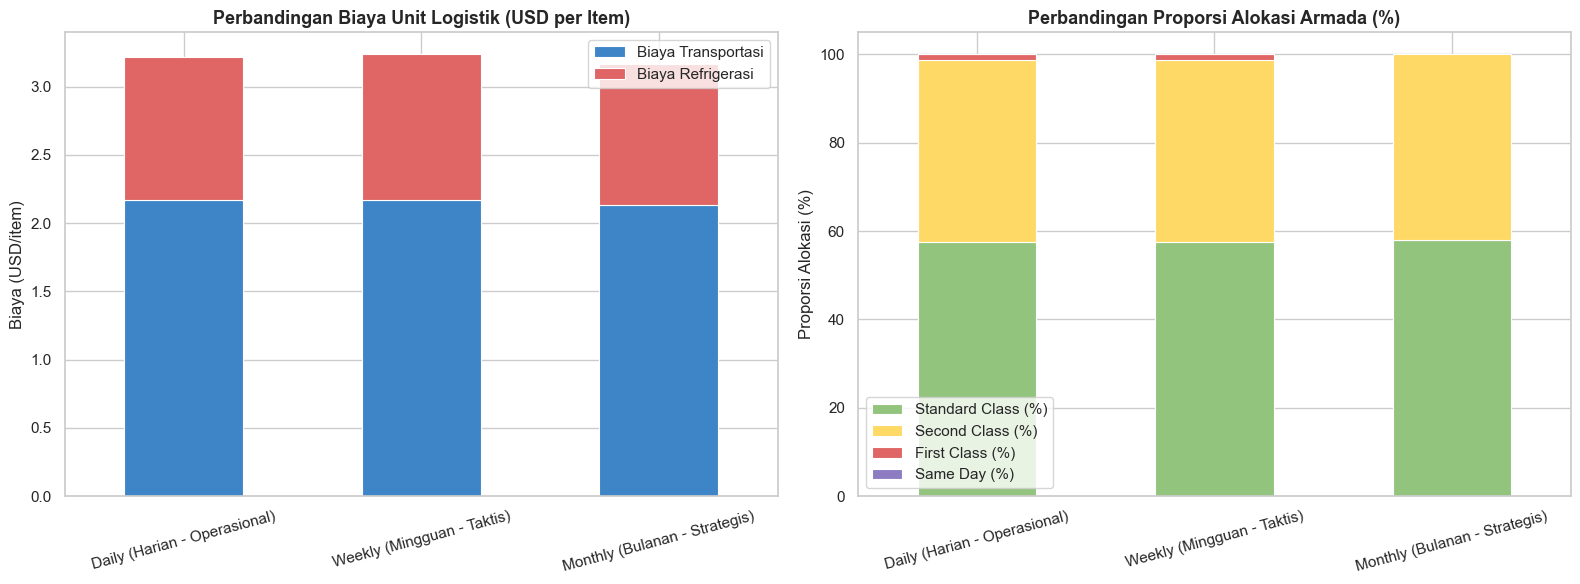

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot Perbandingan Biaya Unit
cost_cols = ['Unit Trans Cost (USD/item)', 'Unit Refrig Cost (USD/item)']
df_comparison[cost_cols].plot(kind='bar', stacked=True, ax=axes[0], color=['#3d85c6', '#e06666'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Perbandingan Biaya Unit Logistik (USD per Item)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Biaya (USD/item)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['Biaya Transportasi', 'Biaya Refrigerasi'])

# 2. Plot Perbandingan Proporsi Moda Alokasi
mode_cols = ['Standard Class (%)', 'Second Class (%)', 'First Class (%)', 'Same Day (%)']
df_comparison[mode_cols].plot(kind='bar', stacked=True, ax=axes[1], color=['#93c47d', '#ffd966', '#e06666', '#8e7cc3'], edgecolor='white', linewidth=0.8)
axes[1].set_title('Perbandingan Proporsi Alokasi Armada (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Proporsi Alokasi (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(mode_cols, loc='lower left')

plt.tight_layout()
plt.show()

## 8. Visualisasi Alokasi Armada Pengiriman Dinamis Harian (Stacked Area)

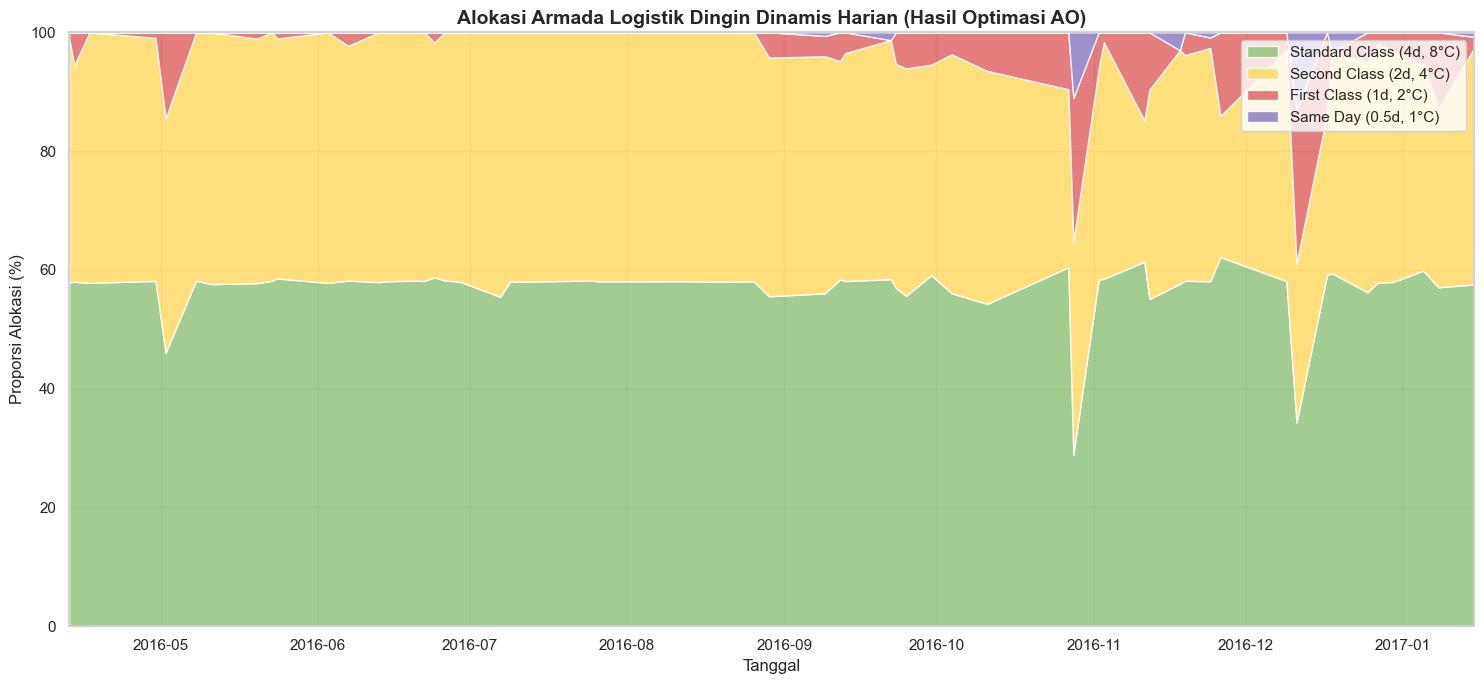

In [7]:
modes = ['x_standard', 'x_second', 'x_first', 'x_same_day']
mode_labels = [
    'Standard Class (4d, 8°C)', 
    'Second Class (2d, 4°C)', 
    'First Class (1d, 2°C)', 
    'Same Day (0.5d, 1°C)'
]

plt.figure(figsize=(15, 7))
plt.stackplot(
    df_opt_daily.index, 
    df_opt_daily['x_standard'] * 100.0,
    df_opt_daily['x_second'] * 100.0,
    df_opt_daily['x_first'] * 100.0,
    df_opt_daily['x_same_day'] * 100.0,
    labels=mode_labels,
    colors=['#93c47d', '#ffd966', '#e06666', '#8e7cc3'],
    alpha=0.85
)

plt.title('Alokasi Armada Logistik Dingin Dinamis Harian (Hasil Optimasi AO)', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Proporsi Alokasi (%)', fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=11)
plt.xlim(df_opt_daily.index.min(), df_opt_daily.index.max())
plt.ylim(0.0, 100.0)
plt.tight_layout()
plt.show()

## 9. Analisis Hubungan Suhu Ambient dengan Alokasi Same Day + First Class

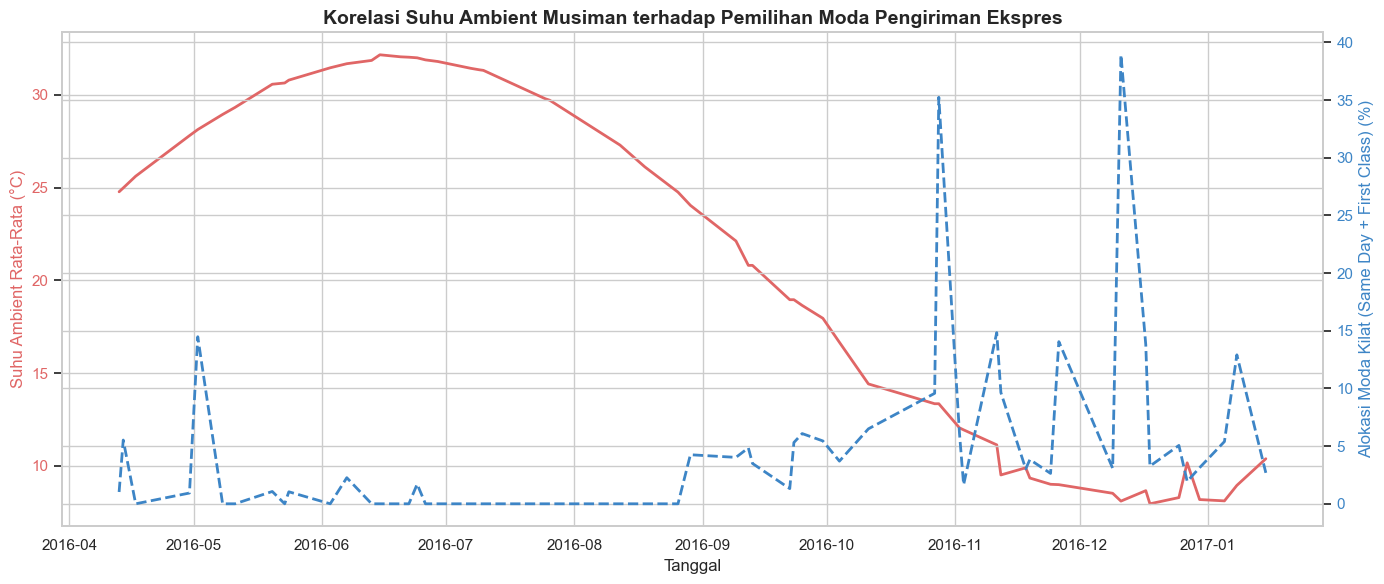

In [8]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Suhu Ambient
color = '#e06666'
ax1.set_xlabel('Tanggal')
ax1.set_ylabel('Suhu Ambient Rata-Rata (°C)', color=color)
ax1.plot(df_opt_daily.index, df_opt_daily['ambient_temp'], color=color, linewidth=2, label='Suhu Ambient')
ax1.tick_params(axis='y', labelcolor=color)

# Sumbu sekunder untuk alokasi pengiriman express (First Class + Same Day)
ax2 = ax1.twinx()
color = '#3d85c6'
ax2.set_ylabel('Alokasi Moda Kilat (Same Day + First Class) (%)', color=color)
express_allocation = (df_opt_daily['x_first'] + df_opt_daily['x_same_day']) * 100.0
ax2.plot(df_opt_daily.index, express_allocation, color=color, linewidth=2, linestyle='--', label='Same Day + First Class %')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Korelasi Suhu Ambient Musiman terhadap Pemilihan Moda Pengiriman Ekspres', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Verifikasi Kualitas Produk Tiba di Tujuan (Daily)

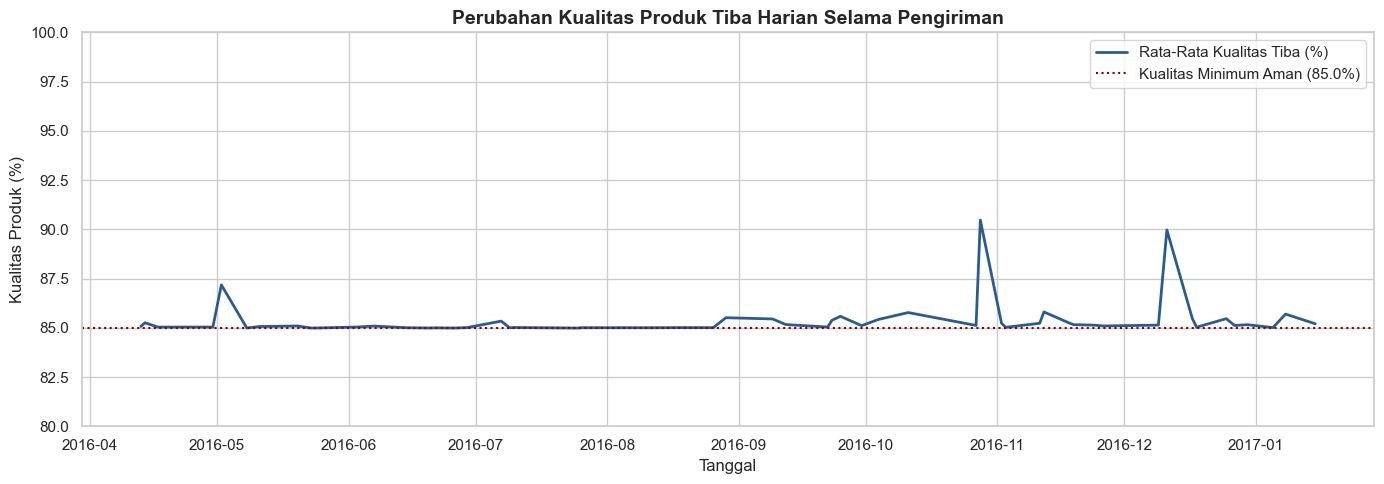

Minimum Kualitas Tiba sepanjang masa uji: 84.98%
Rata-Rata Kualitas Tiba sepanjang masa uji: 85.38%


In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df_opt_daily.index, df_opt_daily['avg_quality_opt'], color='#2b5c8f', linewidth=2, label='Rata-Rata Kualitas Tiba (%)')
plt.axhline(85.0, color='darkred', linestyle=':', label='Kualitas Minimum Aman (85.0%)')
plt.title('Perubahan Kualitas Produk Tiba Harian Selama Pengiriman', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Kualitas Produk (%)')
plt.ylim(80, 100)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Minimum Kualitas Tiba sepanjang masa uji: {df_opt_daily['avg_quality_opt'].min():.2f}%")
print(f"Rata-Rata Kualitas Tiba sepanjang masa uji: {df_opt_daily['avg_quality_opt'].mean():.2f}%")